# Patient Health Record — In-Depth Statistical Analysis

This notebook is designed for the Kaggle **Patient Health Record Raw CSV** dataset and will run even if the full CSV is not available locally yet.

It does three things:
1. loads the full dataset when you provide it,
2. falls back to the 10-row sample you shared if the file is missing,
3. produces a complete exploratory and inferential analysis.

In [7]:
import os
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

In [8]:
# Update this path to your downloaded CSV file.
CSV_PATH = "../data/processed/cleaned_data.csv"

# Fallback sample from the message you shared
sample_csv = '''patient_id,name,age,gender,city,bmi,heart_rate,cholesterol_level,diabetic,smoker,medications,last_visit_date,follow_up,diagnosis_code,notes,has_disease,systolic_bp,diastolic_bp
ID-00001,Alice Smith,50.0,unknown,boston,22.0,83.0,190.0,0.0,smoker,none,2021-04-15,30.0,A00,Patient feeling fine ,0.0,120.0,80.0
ID-00002,Alice Smith,50.0,female,new york,25.8,80.0,180.0,0.0,non-smoker,none,,0.0,UNKNOWN,"BP high, needs recheck",0.0,120.0,80.0
ID-00003,John Doe,50.0,unknown,new york,22.0,80.0,190.0,0.0,former smoker,"aspirin,metformin",2021-04-06,30.0,B20,no notes,0.0,120.0,80.0
ID-00004,Michael Brown,80.0,female,new york,33.4,80.0,250.0,1.0,former smoker,none,,30.0,UNKNOWN,Follow up soon,0.0,120.0,80.0
ID-00005,Jane Doe,50.0,male,los angeles,30.1,80.0,180.0,0.0,non-smoker,none,,0.0,I10,Patient feeling fine ,1.0,120.0,80.0
ID-00006,Michael Brown,50.0,unknown,unknown,22.0,63.0,180.0,0.0,former smoker,none,,30.0,E11.9,no notes,0.0,120.0,80.0
ID-00007,Sara Lee,98.0,male,chicago,22.5,108.0,180.0,0.0,non-smoker,"aspirin,metformin",,0.0,E11.9,Follow up soon,0.0,120.0,80.0
ID-00008,Alice Smith,50.0,male,new york,22.5,85.0,250.0,1.0,unknown,none,2022-05-22,0.0,I10,"BP high, needs recheck",0.0,120.0,80.0
ID-00009,John Doe,50.0,unknown,boston,22.5,80.0,240.0,0.0,former smoker,"aspirin, metformin",,30.0,UNKNOWN,no notes,0.0,120.0,80.0
'''

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"Loaded full dataset from: {CSV_PATH}")
else:
    from io import StringIO
    df = pd.read_csv(StringIO(sample_csv))
    print("CSV file not found. Loaded the 9-row sample from the prompt instead.")

df.head()

Loaded full dataset from: ../data/processed/cleaned_data.csv


,patient_id,name,age,gender,city,bmi,heart_rate,cholesterol_level,diabetic,smoker,medications,last_visit_date,follow_up,diagnosis_code,notes,has_disease,systolic_bp,diastolic_bp
0,ID-00001,Alice Smith,50.0,unknown,boston,22.0,83.0,190.0,0.0,smoker,none,2021-04-15,30.0,A00,Patient feeling fine,0.0,120.0,80.0
1,ID-00002,Alice Smith,50.0,female,new york,25.8,80.0,180.0,0.0,non-smoker,none,NaN,0.0,UNKNOWN,"BP high, needs recheck",0.0,120.0,80.0
2,ID-00003,John Doe,50.0,unknown,new york,22.0,80.0,190.0,0.0,former smoker,"aspirin,metformin",2021-04-06,30.0,B20,no notes,0.0,120.0,80.0
3,ID-00004,Michael Brown,80.0,female,new york,33.4,80.0,250.0,1.0,former smoker,none,NaN,30.0,UNKNOWN,Follow up soon,0.0,120.0,80.0
4,ID-00005,Jane Doe,50.0,male,los angeles,30.1,80.0,180.0,0.0,non-smoker,none,NaN,0.0,I10,Patient feeling fine,1.0,120.0,80.0


In [ ]:
df.info()

In [9]:
# Basic cleaning / normalization
df = df.copy()

# Standardize column names
df.columns = [c.strip().lower() for c in df.columns]

# Trim whitespace from object columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# Convert known binary/boolean-like columns
for col in ["diabetic", "has_disease"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# Clean dates
if "last_visit_date" in df.columns:
    df["last_visit_date"] = pd.to_datetime(df["last_visit_date"], errors="coerce")

# Convert numerics
numeric_cols = ["age", "bmi", "heart_rate", "cholesterol_level", "follow_up", "systolic_bp", "diastolic_bp"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Normalize some text categories
replacements = {
    "gender": {"unknown": np.nan, "nan": np.nan},
    "smoker": {"unknown": np.nan, "nan": np.nan},
    "city": {"unknown": np.nan, "nan": np.nan},
    "diagnosis_code": {"UNKNOWN": np.nan, "unknown": np.nan, "nan": np.nan},
}
for col, mapping in replacements.items():
    if col in df.columns:
        df[col] = df[col].replace(mapping)

df.head()

,patient_id,name,age,gender,city,bmi,heart_rate,cholesterol_level,diabetic,smoker,medications,last_visit_date,follow_up,diagnosis_code,notes,has_disease,systolic_bp,diastolic_bp
0,ID-00001,Alice Smith,50.0,NaN,boston,22.0,83.0,190.0,0,smoker,none,2021-04-15,30.0,A00,Patient feeling fine,0,120.0,80.0
1,ID-00002,Alice Smith,50.0,female,new york,25.8,80.0,180.0,0,non-smoker,none,NaT,0.0,NaN,"BP high, needs recheck",0,120.0,80.0
2,ID-00003,John Doe,50.0,NaN,new york,22.0,80.0,190.0,0,former smoker,"aspirin,metformin",2021-04-06,30.0,B20,no notes,0,120.0,80.0
3,ID-00004,Michael Brown,80.0,female,new york,33.4,80.0,250.0,1,former smoker,none,NaT,30.0,NaN,Follow up soon,0,120.0,80.0
4,ID-00005,Jane Doe,50.0,male,los angeles,30.1,80.0,180.0,0,non-smoker,none,NaT,0.0,I10,Patient feeling fine,1,120.0,80.0


## 1) Dataset overview

In [10]:
print("Shape:", df.shape)
display(df.head(10))
print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())
if "patient_id" in df.columns:
    print("Duplicate patient_id values:", df["patient_id"].duplicated().sum())

Shape: (10000, 18)


,patient_id,name,age,gender,city,bmi,heart_rate,cholesterol_level,diabetic,smoker,medications,last_visit_date,follow_up,diagnosis_code,notes,has_disease,systolic_bp,diastolic_bp
0,ID-00001,Alice Smith,50.0,NaN,boston,22.0,83.0,190.0,0,smoker,none,2021-04-15,30.0,A00,Patient feeling fine,0,120.0,80.0
1,ID-00002,Alice Smith,50.0,female,new york,25.8,80.0,180.0,0,non-smoker,none,NaT,0.0,NaN,"BP high, needs recheck",0,120.0,80.0
2,ID-00003,John Doe,50.0,NaN,new york,22.0,80.0,190.0,0,former smoker,"aspirin,metformin",2021-04-06,30.0,B20,no notes,0,120.0,80.0
3,ID-00004,Michael Brown,80.0,female,new york,33.4,80.0,250.0,1,former smoker,none,NaT,30.0,NaN,Follow up soon,0,120.0,80.0
4,ID-00005,Jane Doe,50.0,male,los angeles,30.1,80.0,180.0,0,non-smoker,none,NaT,0.0,I10,Patient feeling fine,1,120.0,80.0
5,ID-00006,Michael Brown,50.0,NaN,NaN,22.0,63.0,180.0,0,former smoker,none,NaT,30.0,E11.9,no notes,0,120.0,80.0
6,ID-00007,Sara Lee,98.0,male,chicago,22.5,108.0,180.0,0,non-smoker,"aspirin,metformin",NaT,0.0,E11.9,Follow up soon,0,120.0,80.0
7,ID-00008,Alice Smith,50.0,male,new york,22.5,85.0,250.0,1,NaN,none,2022-05-22,0.0,I10,"BP high, needs recheck",0,120.0,80.0
8,ID-00009,John Doe,50.0,NaN,boston,22.5,80.0,240.0,0,former smoker,"aspirin, metformin",NaT,30.0,NaN,no notes,0,120.0,80.0
9,ID-00010,Michael Brown,50.0,NaN,chicago,21.5,80.0,190.0,0,former smoker,none,NaT,30.0,A00,"BP high, needs recheck",1,120.0,80.0



Missing values per column:


,missing_count
last_visit_date,7508
gender,3426
diagnosis_code,3366
smoker,3234
city,1003
patient_id,507
heart_rate,0
cholesterol_level,0
diabetic,0
name,0



Duplicate rows: 0
Duplicate patient_id values: 506


In [11]:
# Summary statistics for numeric columns
num_df = df.select_dtypes(include=[np.number])
display(num_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,10000.0,49.9091,14.701294,0.0,50.0,50.0,50.0,100.0
bmi,10000.0,22.986,3.090008,15.0,22.0,22.5,22.5,35.0
heart_rate,10000.0,81.3729,10.71057,50.0,80.0,80.0,80.0,120.0
cholesterol_level,10000.0,209.506,28.857222,180.0,190.0,190.0,240.0,250.0
diabetic,10000.0,0.3327,0.471204,0.0,0.0,0.0,1.0,1.0
follow_up,10000.0,10.8688,12.361216,0.0,0.0,0.0,14.0,30.0
has_disease,10000.0,0.2461,0.430759,0.0,0.0,0.0,0.0,1.0
systolic_bp,10000.0,120.9135,9.326302,90.0,120.0,120.0,120.0,160.0
diastolic_bp,10000.0,79.9927,5.289862,60.0,80.0,80.0,80.0,100.0


In [12]:
# High-level categorical summaries
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
for col in cat_cols:
    print(f"\nColumn: {col}")
    display(df[col].value_counts(dropna=False).head(10).to_frame("count"))


Column: patient_id


,count
patient_id,
NaN,507
ID-00001,1
ID-00002,1
ID-00003,1
ID-00004,1
ID-00005,1
ID-00006,1
ID-00007,1
ID-00008,1



Column: name


,count
name,
Sara Lee,2038
Alice Smith,2015
Michael Brown,2008
John Doe,1975
Jane Doe,1964



Column: gender


...

,count
medications,
none,4024
"aspirin,metformin",2011
lisinopril / metformin,2011
"aspirin, metformin",1954



Column: diagnosis_code


,count
diagnosis_code,
NaN,3366
B20,1700
I10,1664
E11.9,1663
A00,1607



Column: notes


,count
notes,
no notes,4024
Follow up soon,2023
"BP high, needs recheck",2017
Patient feeling fine,1936


## 2) Univariate analysis

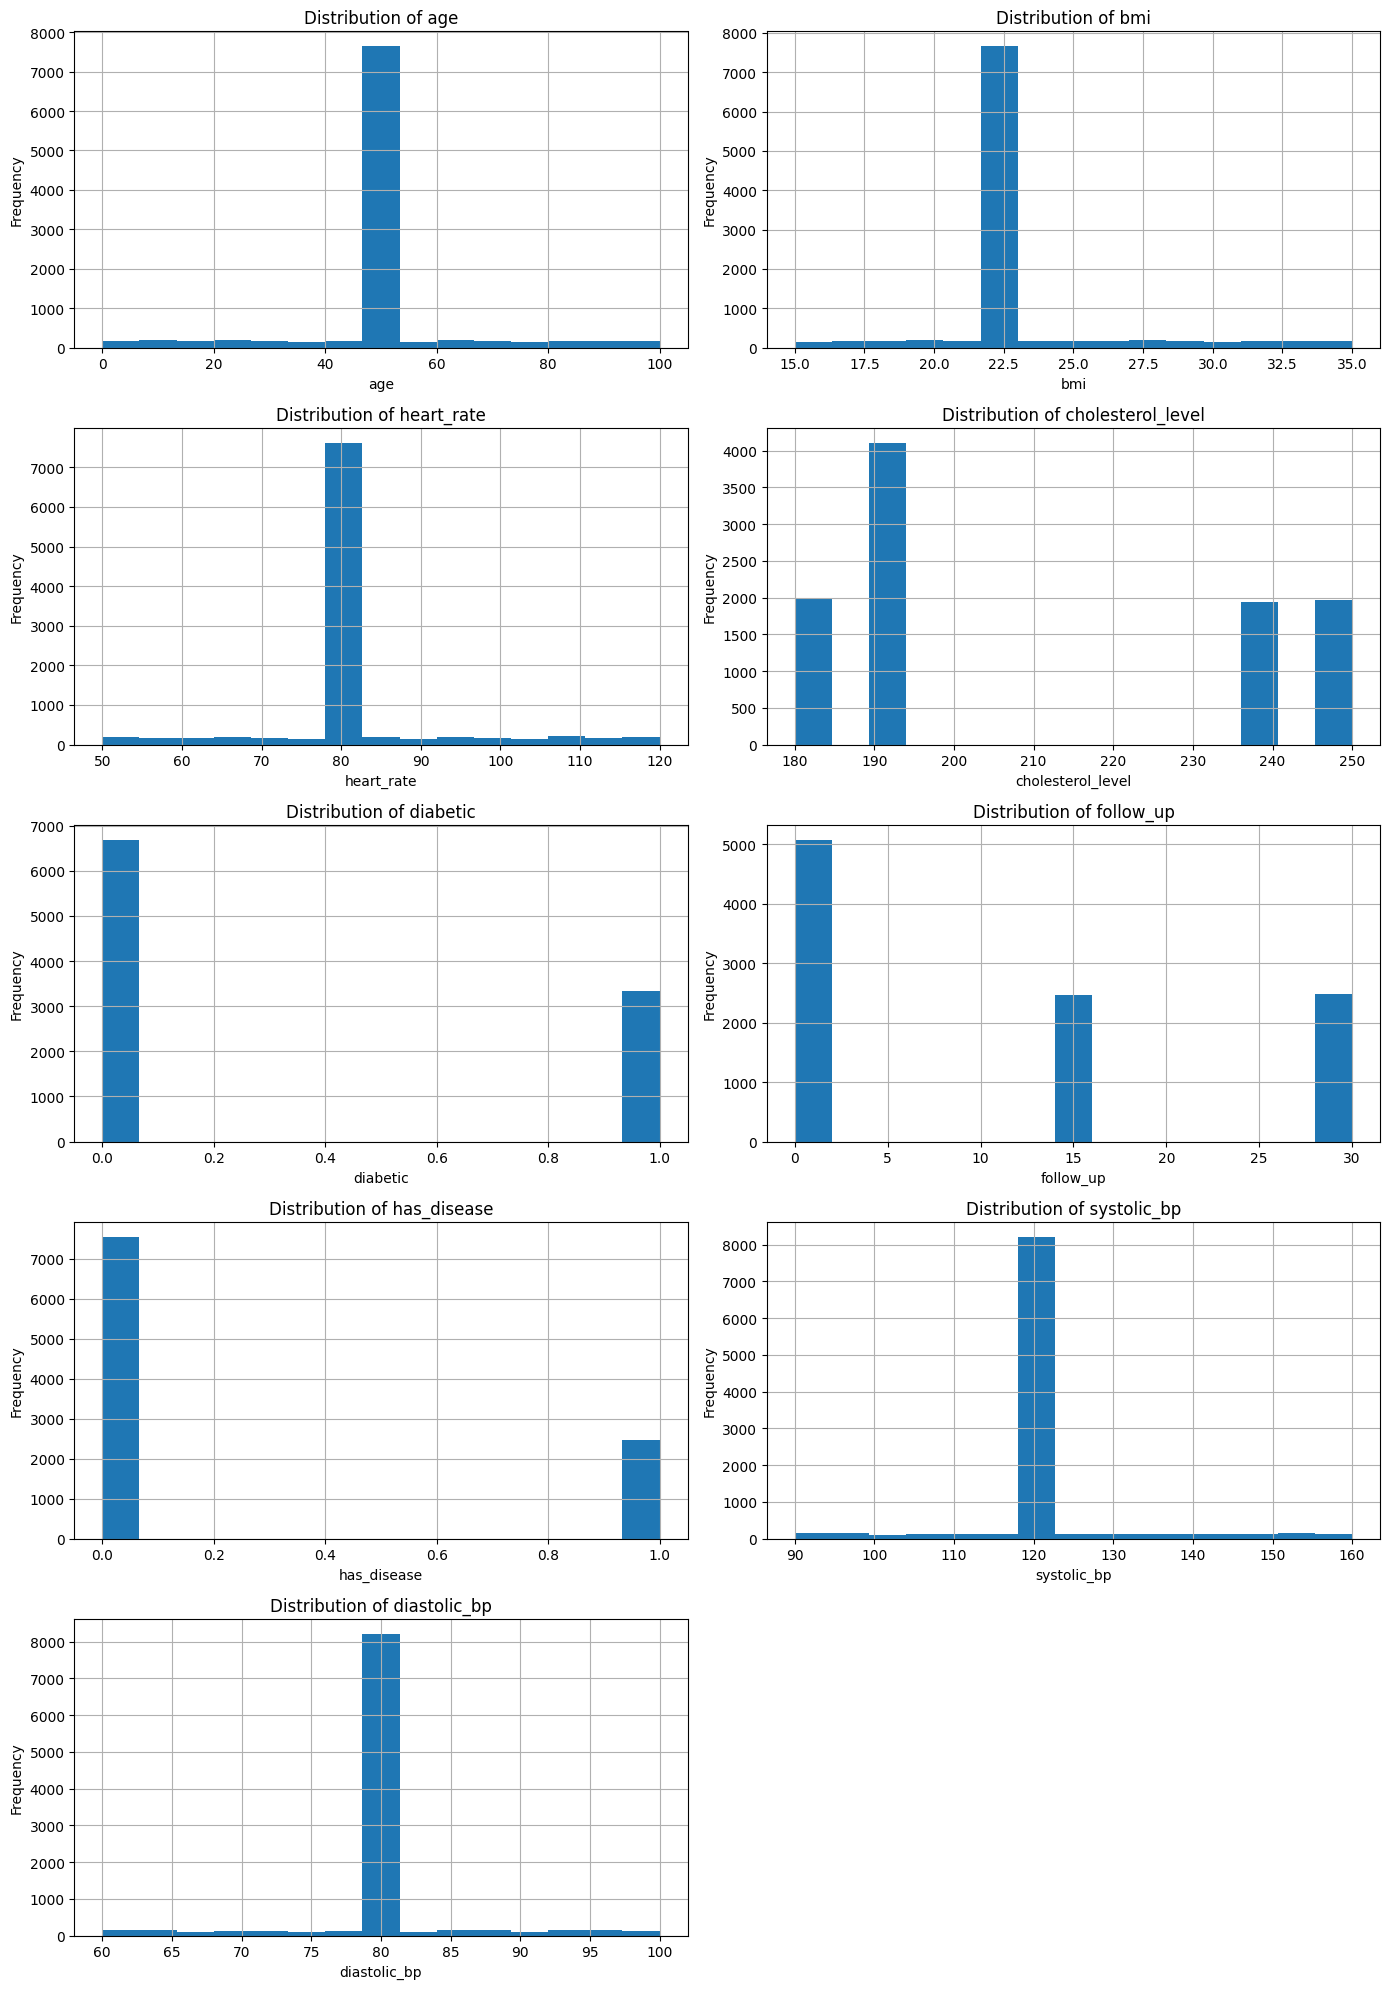

In [13]:
# Histograms for numeric variables
num_cols = num_df.columns.tolist()
n = len(num_cols)
if n > 0:
    rows = math.ceil(n / 2)
    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, num_cols):
        ax.hist(df[col].dropna(), bins=15)
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
    for ax in axes[len(num_cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

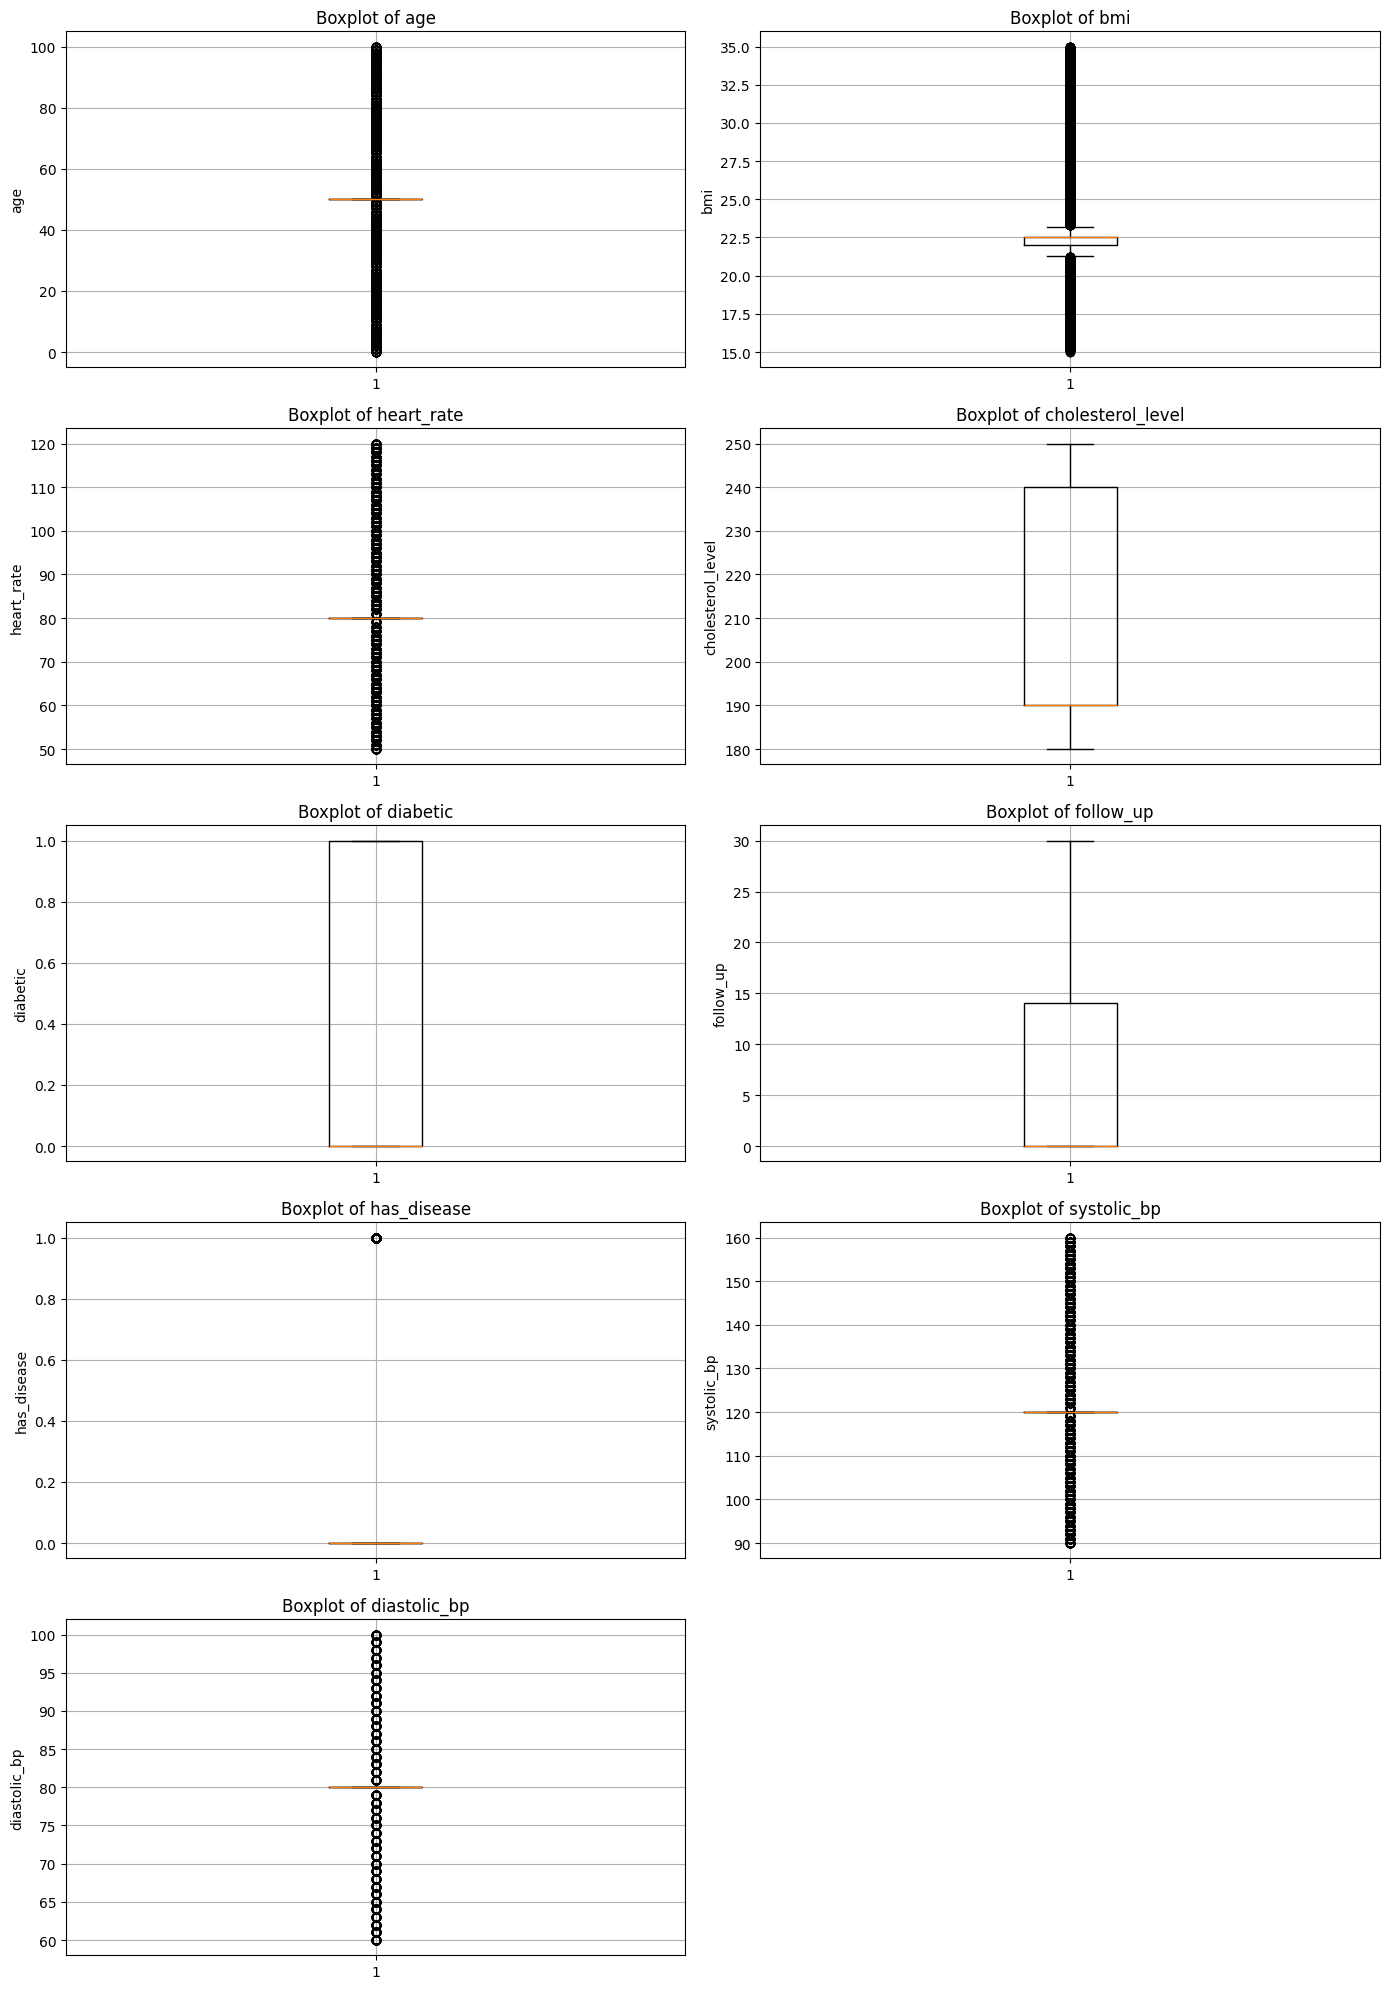

In [14]:
# Boxplots for numeric variables
if n > 0:
    rows = math.ceil(n / 2)
    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, num_cols):
        ax.boxplot(df[col].dropna(), vert=True)
        ax.set_title(f"Boxplot of {col}")
        ax.set_ylabel(col)
    for ax in axes[len(num_cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 3) Target variable exploration

The main outcome appears to be **has_disease**.  
The notebook measures how it relates to age, BMI, cholesterol, blood pressure, heart rate, diabetes, smoking, gender, and city.

Target distribution:


,count
has_disease,
0,7539
1,2461


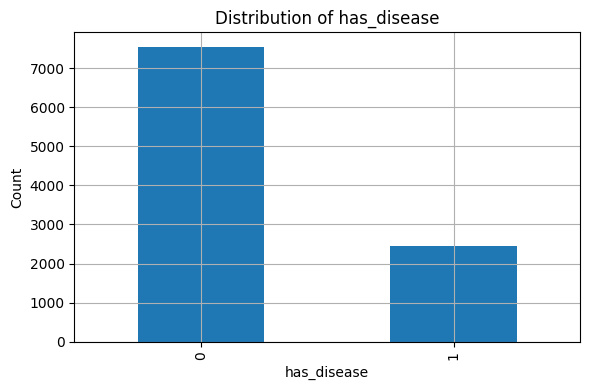

In [15]:
target = "has_disease"

if target in df.columns:
    print("Target distribution:")
    display(df[target].value_counts(dropna=False).rename_axis(target).to_frame("count"))

    fig, ax = plt.subplots(figsize=(6, 4))
    df[target].value_counts(dropna=False).sort_index().plot(kind="bar", ax=ax)
    ax.set_title("Distribution of has_disease")
    ax.set_xlabel("has_disease")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

In [16]:
# Numeric comparison by target
analysis_numeric = [c for c in ["age", "bmi", "heart_rate", "cholesterol_level", "systolic_bp", "diastolic_bp", "follow_up"] if c in df.columns]

for col in analysis_numeric:
    print(f"\n=== {col} by has_disease ===")
    grp = df.groupby(target)[col].agg(["count", "mean", "median", "std", "min", "max"])
    display(grp)

    groups = [g[col].dropna().values for _, g in df.groupby(target)]
    if len(groups) >= 2 and all(len(g) >= 2 for g in groups[:2]):
        try:
            u_stat, p_val = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
            print(f"Mann–Whitney U p-value: {p_val:.4g}")
        except Exception as e:
            print("Test could not be computed:", e)


=== age by has_disease ===


,count,mean,median,std,min,max
has_disease,,,,,,
0,7539,50.045364,50.0,14.724337,0.0,100.0
1,2461,49.491670,50.0,14.625558,0.0,100.0


Mann–Whitney U p-value: 0.2523

=== bmi by has_disease ===


,count,mean,median,std,min,max
has_disease,,,,,,
0,7539,22.990344,22.5,3.121049,15.0,35.0
1,2461,22.972694,22.5,2.993496,15.3,35.0


Mann–Whitney U p-value: 0.4854

=== heart_rate by has_disease ===


...

Mann–Whitney U p-value: 0.3011

=== diastolic_bp by has_disease ===


,count,mean,median,std,min,max
has_disease,,,,,,
0,7539,79.958880,80.0,5.287506,60.0,100.0
1,2461,80.096302,80.0,5.296807,60.0,100.0


Mann–Whitney U p-value: 0.3434

=== follow_up by has_disease ===


,count,mean,median,std,min,max
has_disease,,,,,,
0,7539,10.882876,0.0,12.356620,0.0,30.0
1,2461,10.825681,0.0,12.377698,0.0,30.0


Mann–Whitney U p-value: 0.8005


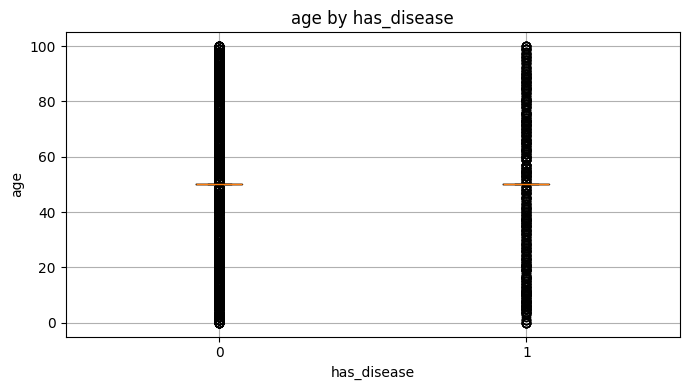

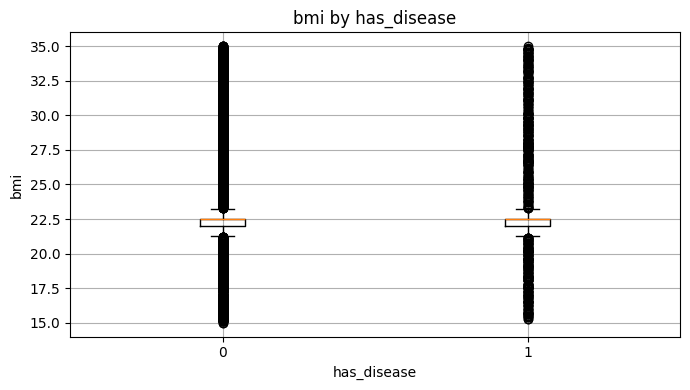

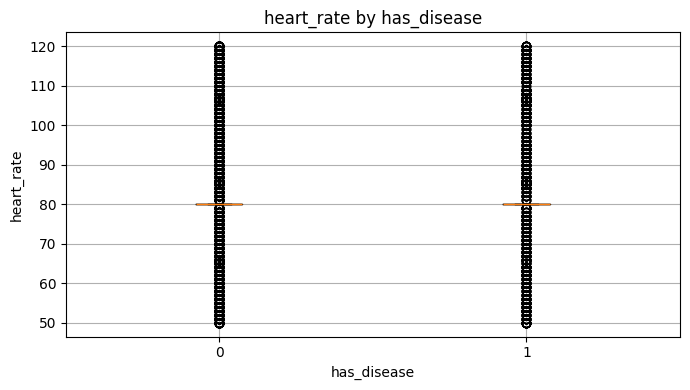

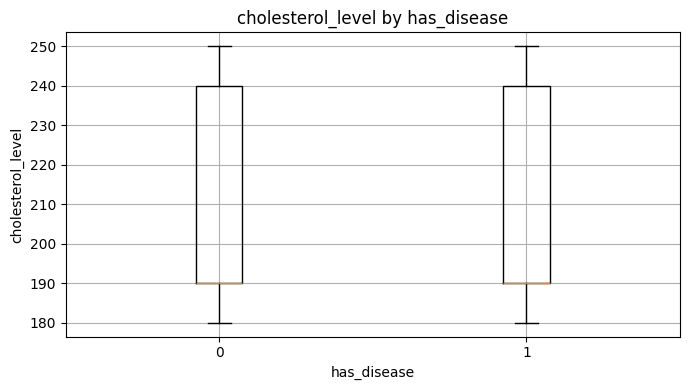

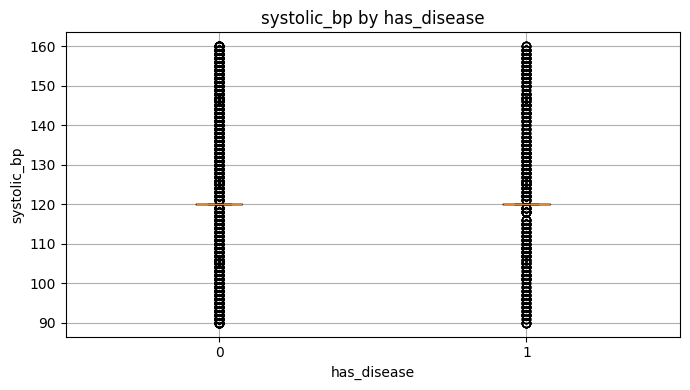

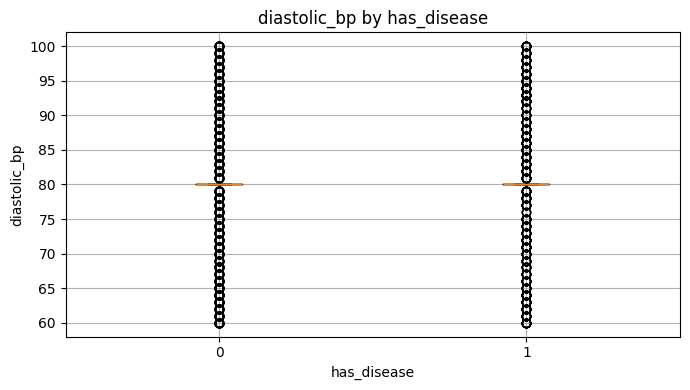

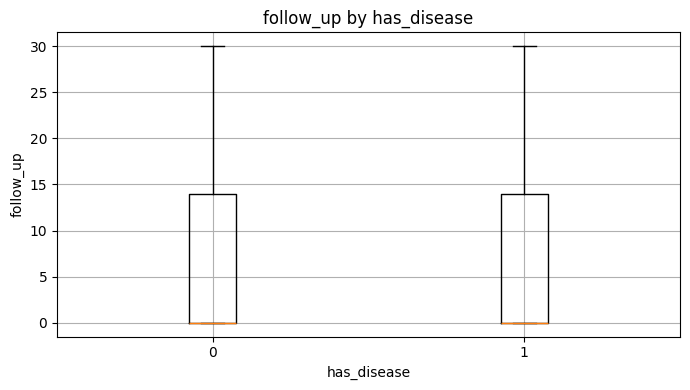

In [17]:
# Boxplots of numeric variables by disease status
analysis_numeric = [c for c in ["age", "bmi", "heart_rate", "cholesterol_level", "systolic_bp", "diastolic_bp", "follow_up"] if c in df.columns]

for col in analysis_numeric:
    fig, ax = plt.subplots(figsize=(7, 4))
    present_targets = sorted(df[target].dropna().unique())
    data = [df.loc[df[target] == v, col].dropna() for v in present_targets]
    if len(data) >= 2:
        ax.boxplot(data, labels=[str(v) for v in present_targets])
        ax.set_title(f"{col} by has_disease")
        ax.set_xlabel("has_disease")
        ax.set_ylabel(col)
        plt.tight_layout()
        plt.show()

## 4) Categorical associations

In [18]:
def crosstab_with_chi2(data, col, target="has_disease"):
    tbl = pd.crosstab(data[col], data[target], dropna=False)
    display(tbl)
    if tbl.shape[0] > 1 and tbl.shape[1] > 1:
        chi2, p, dof, expected = stats.chi2_contingency(tbl)
        print(f"Chi-square p-value for {col} vs {target}: {p:.4g}")
    else:
        print("Not enough category variety for chi-square test.")

for col in [c for c in ["gender", "smoker", "city", "diabetic", "diagnosis_code"] if c in df.columns]:
    print(f"\n=== {col} vs {target} ===")
    crosstab_with_chi2(df, col, target)


=== gender vs has_disease ===


has_disease,0,1
gender,,
female,2439,825
male,2520,790
NaN,2580,846


Chi-square p-value for gender vs has_disease: 0.4112

=== smoker vs has_disease ===


has_disease,0,1
smoker,,
former smoker,2609,848
non-smoker,1241,422
smoker,1241,405
NaN,2448,786


Chi-square p-value for smoker vs has_disease: 0.8731

=== city vs has_disease ===


...

Chi-square p-value for city vs has_disease: 0.4859

=== diabetic vs has_disease ===


has_disease,0,1
diabetic,,
0,5022,1651
1,2517,810


Chi-square p-value for diabetic vs has_disease: 0.6835

=== diagnosis_code vs has_disease ===


has_disease,0,1
diagnosis_code,,
A00,1228,379
B20,1248,452
E11.9,1260,403
I10,1270,394
NaN,2533,833


Chi-square p-value for diagnosis_code vs has_disease: 0.2453


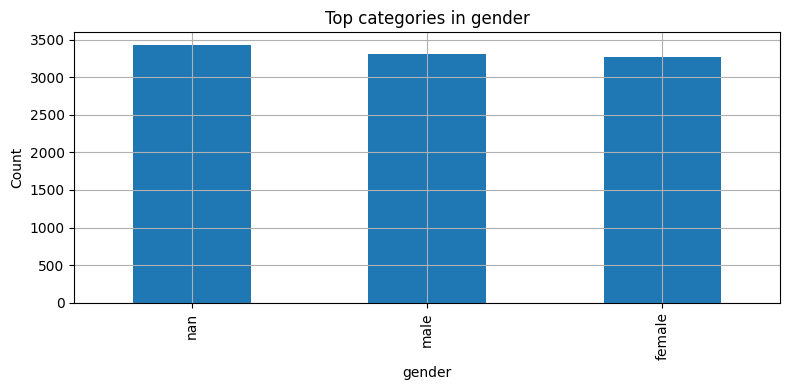

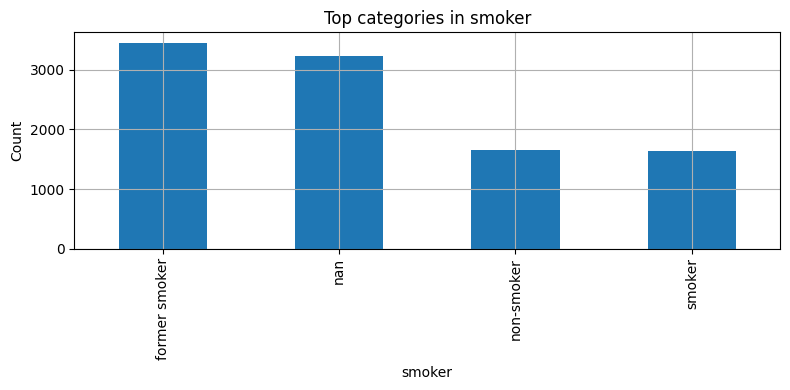

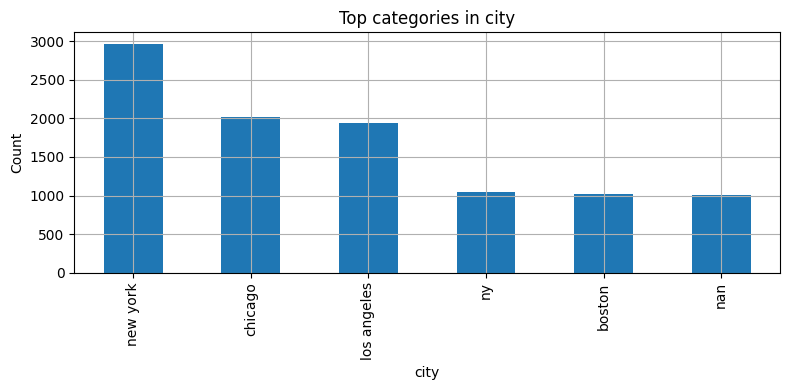

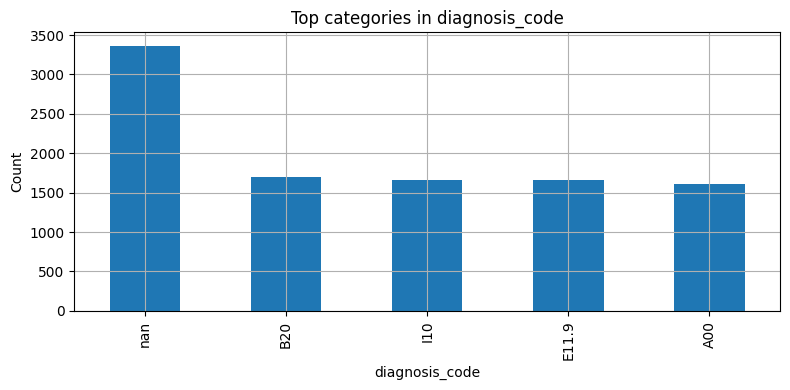

In [19]:
# Bar charts for key categoricals
for col in [c for c in ["gender", "smoker", "city", "diagnosis_code"] if c in df.columns]:
    top = df[col].value_counts(dropna=False).head(10)
    fig, ax = plt.subplots(figsize=(8, 4))
    top.plot(kind="bar", ax=ax)
    ax.set_title(f"Top categories in {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

## 5) Correlation analysis

,age,bmi,heart_rate,cholesterol_level,diabetic,follow_up,has_disease,systolic_bp,diastolic_bp
age,1.000,0.011,0.013,0.002,-0.000,-0.003,-0.016,-0.009,-0.015
bmi,0.011,1.000,-0.005,-0.005,0.001,0.000,-0.002,0.004,0.005
heart_rate,0.013,-0.005,1.000,0.016,0.005,-0.017,0.008,-0.006,0.002
cholesterol_level,0.002,-0.005,0.016,1.000,0.018,-0.012,-0.006,-0.013,0.003
diabetic,-0.000,0.001,0.005,0.018,1.000,-0.003,-0.004,0.007,-0.003
follow_up,-0.003,0.000,-0.017,-0.012,-0.003,1.000,-0.002,-0.006,-0.002
has_disease,-0.016,-0.002,0.008,-0.006,-0.004,-0.002,1.000,0.008,0.011
systolic_bp,-0.009,0.004,-0.006,-0.013,0.007,-0.006,0.008,1.000,-0.007
diastolic_bp,-0.015,0.005,0.002,0.003,-0.003,-0.002,0.011,-0.007,1.000


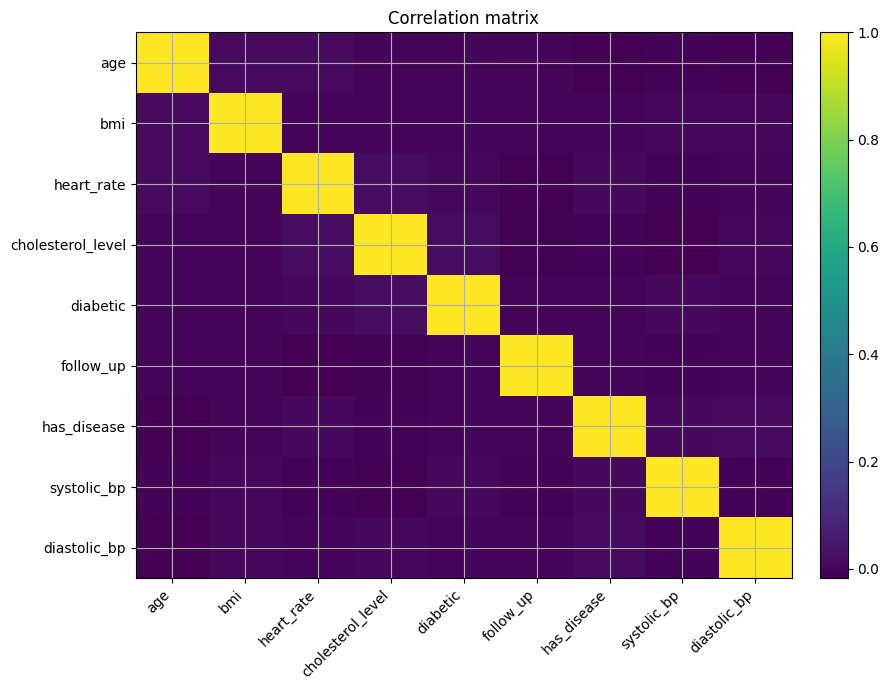

In [20]:
# Correlation matrix for numeric columns
if len(num_cols) > 1:
    corr = df[num_cols].corr(numeric_only=True)
    display(corr.round(3))

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr, aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.index)
    ax.set_title("Correlation matrix")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

In [ ]:
# Spearman correlation with target if numeric and present
if target in df.columns and pd.api.types.is_numeric_dtype(df[target]):
    target_corr = []
    for col in num_cols:
        if col != target and df[col].notna().sum() >= 3:
            rho, p = stats.spearmanr(df[col], df[target], nan_policy="omit")
            target_corr.append((col, rho, p))
    if target_corr:
        target_corr_df = pd.DataFrame(target_corr, columns=["feature", "spearman_rho", "p_value"]).sort_values(
            by="spearman_rho", key=lambda s: s.abs(), ascending=False
        )
        display(target_corr_df)

## 6) Data quality checks

,missing_%
last_visit_date,75.08
gender,34.26
diagnosis_code,33.66
smoker,32.34
city,10.03
patient_id,5.07
heart_rate,0.00
cholesterol_level,0.00
diabetic,0.00
name,0.00


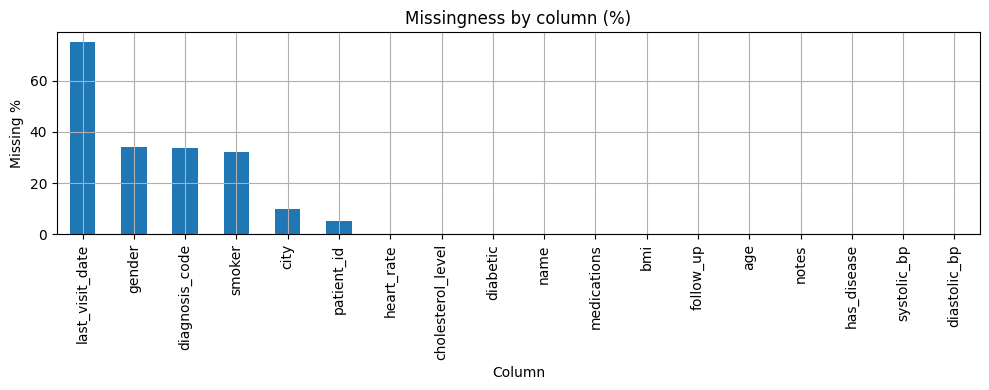

In [21]:
# Missingness pattern
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.to_frame("missing_%"))

fig, ax = plt.subplots(figsize=(10, 4))
missing_pct.plot(kind="bar", ax=ax)
ax.set_title("Missingness by column (%)")
ax.set_xlabel("Column")
ax.set_ylabel("Missing %")
plt.tight_layout()
plt.show()

In [22]:
# Duplicate patient IDs and duplicate full records
if "patient_id" in df.columns:
    dup_ids = df[df["patient_id"].duplicated(keep=False)].sort_values("patient_id")
    print("Rows with duplicate patient_id:")
    display(dup_ids if not dup_ids.empty else pd.DataFrame({"message": ["No duplicate patient_id found"]}))

dup_rows = df[df.duplicated(keep=False)]
print("Rows that are duplicated across all columns:")
display(dup_rows if not dup_rows.empty else pd.DataFrame({"message": ["No full-row duplicates found"]}))

Rows with duplicate patient_id:


,patient_id,name,age,gender,city,bmi,heart_rate,cholesterol_level,diabetic,smoker,medications,last_visit_date,follow_up,diagnosis_code,notes,has_disease,systolic_bp,diastolic_bp
25,NaN,Jane Doe,50.0,female,ny,22.5,80.0,190.0,0,NaN,none,NaT,0.0,NaN,no notes,0,120.0,80.0
40,NaN,Michael Brown,50.0,NaN,new york,22.0,80.0,180.0,0,non-smoker,none,NaT,14.0,B20,Patient feeling fine,1,120.0,80.0
41,NaN,Alice Smith,50.0,NaN,boston,22.5,80.0,240.0,0,NaN,lisinopril / metformin,NaT,0.0,NaN,"BP high, needs recheck",0,90.0,74.0
43,NaN,John Doe,50.0,NaN,new york,17.6,80.0,240.0,0,NaN,"aspirin,metformin",2024-08-10,0.0,B20,no notes,0,120.0,80.0
78,NaN,Michael Brown,3.0,female,boston,24.9,63.0,190.0,0,smoker,"aspirin,metformin",NaT,14.0,E11.9,Follow up soon,0,120.0,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9905,NaN,John Doe,50.0,male,chicago,22.5,80.0,180.0,0,non-smoker,none,2024-11-01,14.0,NaN,"BP high, needs recheck",0,146.0,94.0
9928,NaN,Michael Brown,50.0,male,new york,17.2,80.0,240.0,0,NaN,lisinopril / metformin,NaT,0.0,NaN,no notes,1,94.0,61.0
9939,NaN,Alice Smith,50.0,male,new york,22.5,80.0,190.0,1,former smoker,lisinopril / metformin,NaT,0.0,B20,Patient feeling fine,0,134.0,63.0
9955,NaN,Alice Smith,50.0,male,los angeles,22.5,80.0,240.0,1,NaN,none,NaT,30.0,NaN,"BP high, needs recheck",0,120.0,80.0


Rows that are duplicated across all columns:


,message
0,No full-row duplicates found


In [23]:
# Simple outlier detection using IQR
def iqr_outliers(series):
    s = series.dropna()
    if len(s) < 4:
        return pd.Series(dtype=series.dtype)
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

for col in num_cols:
    out = iqr_outliers(df[col])
    if len(out) > 0:
        print(f"{col}: {len(out)} potential outlier(s)")
        display(df.loc[out.index, [c for c in ["patient_id", col] if c in df.columns]])

age: 2525 potential outlier(s)


,patient_id,age
3,ID-00004,80.0
6,ID-00007,98.0
15,ID-00016,6.0
23,ID-00024,18.0
27,ID-00028,59.0
...,...,...
9980,ID-09981,63.0
9990,ID-09991,22.0
9991,ID-09992,18.0
9993,ID-09994,88.0


bmi: 2253 potential outlier(s)


,patient_id,bmi
1,ID-00002,25.8
3,ID-00004,33.4
4,ID-00005,30.1
17,ID-00018,15.6
24,ID-00025,27.8
...,...,...
9979,ID-09980,29.4
9980,ID-09981,23.5
9981,ID-09982,26.7
9984,ID-09985,24.1


heart_rate: 2536 potential outlier(s)


...

,patient_id,has_disease
4,ID-00005,1
9,ID-00010,1
12,ID-00013,1
15,ID-00016,1
24,ID-00025,1
...,...,...
9969,ID-09970,1
9974,ID-09975,1
9982,ID-09983,1
9984,ID-09985,1


systolic_bp: 1935 potential outlier(s)


,patient_id,systolic_bp
12,ID-00013,115.0
18,ID-00019,106.0
22,ID-00023,141.0
23,ID-00024,91.0
24,ID-00025,139.0
...,...,...
9986,ID-09987,160.0
9989,ID-09990,136.0
9991,ID-09992,125.0
9993,ID-09994,92.0


diastolic_bp: 1910 potential outlier(s)


,patient_id,diastolic_bp
12,ID-00013,61.0
18,ID-00019,68.0
22,ID-00023,60.0
23,ID-00024,89.0
24,ID-00025,96.0
...,...,...
9986,ID-09987,97.0
9989,ID-09990,72.0
9991,ID-09992,70.0
9993,ID-09994,66.0


## 7) Suggested summary to write up after running the notebook

Use these headings in your report:

- Data shape and column types
- Missing values and duplicate IDs
- Distribution of age, BMI, cholesterol, heart rate, and blood pressure
- Comparison of features by `has_disease`
- Associations between disease status and smoking/diabetes/gender/city
- Correlation matrix and strongest relationships
- Outliers and suspicious records
- Practical data-quality observations

If you paste the full CSV into the same folder and re-run the notebook, the outputs will reflect the complete dataset rather than the 9-row fallback sample.